# Ajuste lineal por mínimos cuadrados

Implementación y aplicación del **método de mínimos cuadrados** para obtener una recta que represente la tendencia de un conjunto de datos.

### Objetivos

- Comprender el fundamento del ajuste lineal por mínimos cuadrados.
- Calcular la pendiente y el intercepto de la recta de mejor ajuste.
- Aplicar el método a datos experimentales.
- Representar gráficamente los datos observados y el modelo obtenido.
- Interpretar los parámetros de la recta en el contexto de cada problema.

**Tecnologías:** Python · NumPy · Matplotlib

## 1. Fundamento del método

Cuando un conjunto de datos no se ajusta exactamente a una misma recta, el método de **mínimos cuadrados** permite encontrar un modelo lineal de la forma:

$y=mx+b$

donde:

- $m$ es la pendiente de la recta;
- $b$ es el intercepto con el eje vertical.

El objetivo es minimizar la suma de los cuadrados de los residuos:

$$
S=\sum_{i=1}^{n}\left(y_i-(mx_i+b)\right)^2
$$

Para una regresión lineal simple, los coeficientes pueden calcularse mediante:

$$
m=
\frac{
n\sum x_i y_i-\left(\sum x_i\right)\left(\sum y_i\right)
}{
n\sum x_i^2-\left(\sum x_i\right)^2
}
$$

$$
b=
\frac{
\left(\sum x_i^2\right)\left(\sum y_i\right)
-\left(\sum x_i\right)\left(\sum x_i y_i\right)
}{
n\sum x_i^2-\left(\sum x_i\right)^2
}
$$

A diferencia de la interpolación, la recta de mínimos cuadrados **no necesita pasar exactamente por todos los puntos**. Su objetivo es representar de la mejor manera posible la tendencia general de los datos.

## 2. Aplicación 1 — Elongación de un resorte

Se estudia el alargamiento de un resorte sometido a fuerzas de diferentes magnitudes.

| Fuerza (kgf) | 0 | 2 | 3 | 6 | 7 |
|---|---:|---:|---:|---:|---:|
| Elongación (m) | 0.120 | 0.153 | 0.170 | 0.225 | 0.260 |

El objetivo es obtener mediante mínimos cuadrados el polinomio de primer grado que mejor representa la relación entre la fuerza aplicada y la elongación observada.

Pendiente 0.019433734939759053, Intercepto 0.11563855421686738


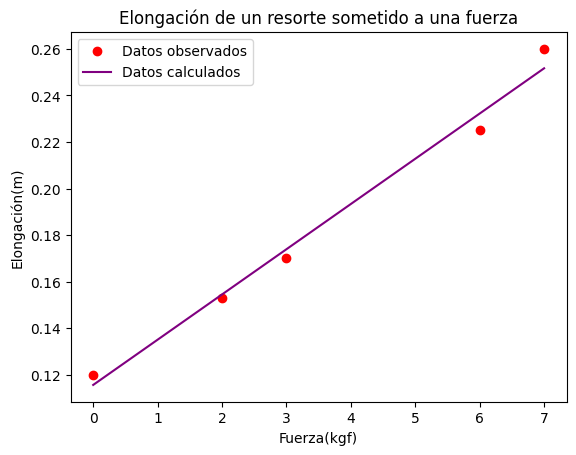

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_data=np.array([0,2,3,6,7])
y_data=np.array([0.12,0.153,0.170,0.225,0.260])

def MinimosCuadrados(x_data, y_data):
    n=len(x_data)
    sum_x = sum(x_data)
    sum_y = sum(y_data)
    sum_yx = sum(x_data*y_data)
    sum_x_square = sum(x_data**2)
    m = (n*sum_yx - sum_x * sum_y) / (n*sum_x_square - sum_x**2)
    b = (sum_x_square * sum_y - sum_x * sum_yx) / (n*sum_x_square - sum_x**2)
    return m, b

m, b = MinimosCuadrados(x_data, y_data)
print(f'Pendiente {m}, Intercepto {b}')

# Polinomio línea recta
P_linea = lambda x: m*x+b

# Gráfica
ux= np.linspace(min(x_data), max(x_data), 2)
plt.plot (x_data, y_data, 'or', label = 'Datos observados')
plt.plot(ux, P_linea(ux), 'purple', label='Datos calculados')
plt.xlabel('Fuerza(kgf)')
plt.ylabel('Elongación(m)')
plt.title('Elongación de un resorte sometido a una fuerza')
plt.legend()
plt.show()

### Interpretación del resultado

El método obtiene aproximadamente:

$m=0.01943$

$b=0.11564$

Por lo tanto, la recta de ajuste es:

$y\approx0.01943x+0.11564$

La pendiente indica el incremento aproximado de la elongación por cada unidad adicional de fuerza aplicada. El intercepto representa el valor estimado de la elongación cuando la fuerza es cero.

La gráfica permite comparar los datos experimentales con la tendencia lineal calculada mediante mínimos cuadrados.

## 3. Aplicación 2 — Contador de lectura de una grabadora

Se recolectaron datos relacionados con el contador de lectura de una grabadora y su tiempo de uso.

| Contador $c_i$ | 100 | 200 | 300 | 400 | 500 | 600 | 700 | 800 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Tiempo $t_i$ | 205 | 430 | 677 | 945 | 1233 | 1542 | 1872 | 2224 |

En este ejercicio se busca construir un modelo lineal que describa la relación entre el contador de lectura y el tiempo transcurrido de uso.

Pendiente 2.884047619047619, Intercepto -156.82142857142858


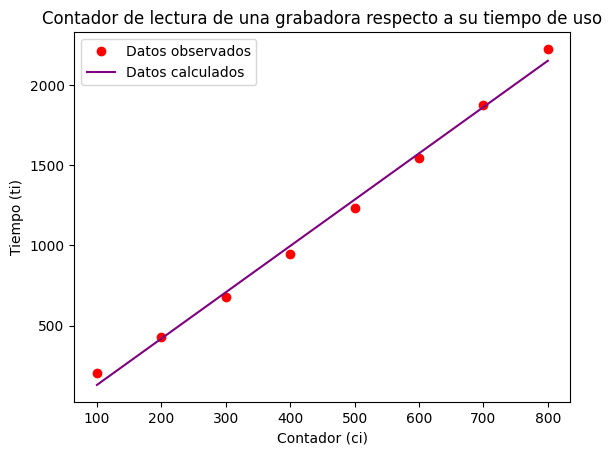

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_data = np.array([100, 200, 300, 400, 500, 600, 700, 800])
y_data = np.array([205, 430, 677, 945, 1233, 1542, 1872, 2224])

def MinimosCuadrados(x_data, y_data):
    n=len(x_data)
    sum_x = sum(x_data)
    sum_y = sum(y_data)
    sum_yx = sum(x_data*y_data)
    sum_x_square = sum(x_data**2)
    m = (n*sum_yx - sum_x * sum_y) / (n*sum_x_square - sum_x**2)
    b = (sum_x_square * sum_y - sum_x * sum_yx) / (n*sum_x_square - sum_x**2)
    return m, b

m, b = MinimosCuadrados(x_data, y_data)
print(f'Pendiente {m}, Intercepto {b}')

# Polinomio línea recta
P_linea = lambda x: m*x+b

# Gráfica
ux= np.linspace(min(x_data), max(x_data), 2)
plt.plot (x_data, y_data, 'or', label = 'Datos observados')
plt.plot(ux, P_linea(ux), 'purple', label='Datos calculados')
plt.xlabel('Contador (ci)')
plt.ylabel('Tiempo (ti)')
plt.title('Contador de lectura de una grabadora respecto a su tiempo de uso')
plt.legend()
plt.show()

### Interpretación del resultado

El ajuste lineal obtiene aproximadamente:

$m=2.88405$

$b=-156.82143$

Por lo tanto, el modelo queda:

$t(c)\approx2.88405c-156.82143$

La pendiente indica el incremento estimado del tiempo de uso por cada unidad adicional del contador. El intercepto forma parte del modelo matemático ajustado y debe interpretarse con precaución si se utiliza fuera del intervalo observado.

La gráfica permite visualizar cómo la recta de mínimos cuadrados sigue la tendencia creciente de los datos sin necesidad de pasar exactamente por cada punto.

## 4. Diferencia entre interpolación y mínimos cuadrados

Los ejercicios de este notebook utilizan **mínimos cuadrados**, cuyo propósito es encontrar una función que represente la tendencia general de los datos.

Esto se diferencia de la interpolación:

- **Interpolación:** construye una función que pasa por todos los puntos conocidos.
- **Mínimos cuadrados:** construye una función que minimiza globalmente las diferencias entre los valores observados y los valores calculados.

Por esta razón, mínimos cuadrados resulta especialmente útil cuando los datos provienen de mediciones experimentales o presentan variaciones que no deberían reproducirse exactamente.

## 5. Conclusiones

A partir de los ejercicios desarrollados se puede concluir que:

- El método de mínimos cuadrados permite obtener una recta que representa la tendencia de un conjunto de datos.
- La pendiente y el intercepto se calculan a partir de sumas realizadas sobre todos los pares de datos disponibles.
- El modelo obtenido no necesita pasar exactamente por cada observación.
- La representación gráfica facilita la comparación entre los datos originales y la recta calculada.
- El método puede utilizarse para analizar relaciones experimentales, como la deformación de un resorte, y relaciones empíricas, como el contador y el tiempo de uso de una grabadora.
- La interpretación del modelo debe realizarse principalmente dentro del intervalo donde se encuentran los datos observados.